In [ ]:
!pip install kagglehub
!pip install matplotlib
!pip install Pillow

In [ ]:
!pip install opencv-python

In [ ]:
import kagglehub

# Download the dataset
dataset_path = kagglehub.dataset_download("gpiosenka/cards-image-datasetclassification")

print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'cards-image-datasetclassification' dataset.
Path to dataset files: /kaggle/input/cards-image-datasetclassification


Total images found: 8154
Image 1 - Name: 5.jpg, Path: /kaggle/input/cards-image-datasetclassification/valid/ace of spades/5.jpg, Size: (224, 224), Mode: RGB


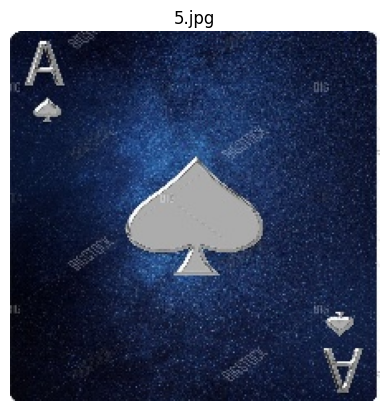

Image 2 - Name: 1.jpg, Path: /kaggle/input/cards-image-datasetclassification/valid/ace of spades/1.jpg, Size: (224, 224), Mode: RGB


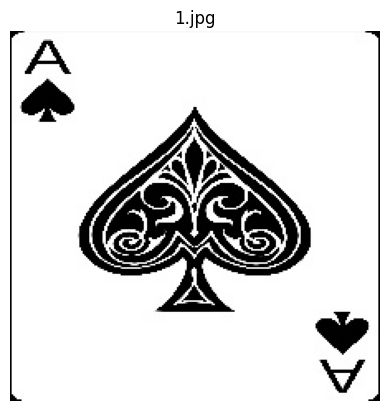

Image 3 - Name: 4.jpg, Path: /kaggle/input/cards-image-datasetclassification/valid/ace of spades/4.jpg, Size: (224, 224), Mode: RGB


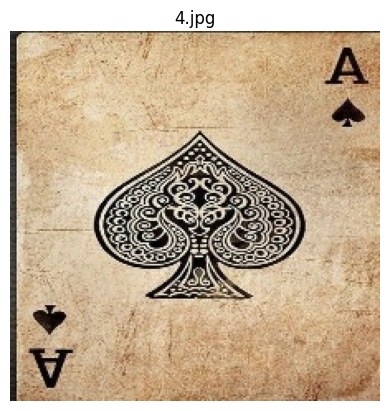

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# List all images recursively within the dataset path
all_images = []
for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_images.append(os.path.join(root, file))

print(f"Total images found: {len(all_images)}")

# Show first 3 images with info
for i, img_path in enumerate(all_images[:3]):
    img_name = os.path.basename(img_path)
    img = Image.open(img_path)
    print(f"Image {i+1} - Name: {img_name}, Path: {img_path}, Size: {img.size}, Mode: {img.mode}")

    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')
    plt.show()

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
import random

# Target folder in Drive
target_dir = "/content/drive/MyDrive/cards_dataset_200"
os.makedirs(target_dir, exist_ok=True)

# Randomly select 200 images, ensure not to sample more images than available
num_images_to_sample = min(200, len(all_images))
sampled_images = random.sample(all_images, num_images_to_sample)

# Copy selected images to target folder
for img_path in sampled_images:
    img_name = os.path.basename(img_path)
    shutil.copy(img_path, os.path.join(target_dir, img_name))

print(f"✅ {num_images_to_sample} images copied to: {target_dir}")

✅ 200 images copied to: /content/drive/MyDrive/cards_dataset_200


In [ ]:
print("Files in the new dataset folder:", os.listdir(target_dir)[:10])  # Show first 10 files
print("Total images:", len(os.listdir(target_dir)))

Files in the new dataset folder: ['046.jpg', '064.jpg', '135.jpg', '005.jpg', '123.jpg', '041.jpg', '160.jpg', '098.jpg', '013.jpg', '077.jpg']
Total images: 145


In [ ]:
# Choose one image from the all_images list
selected_image_path = all_images[0]

# Load the selected image using Pillow
selected_image = Image.open(selected_image_path)

print(f"Selected image path: {selected_image_path}")
print(f"Selected image size: {selected_image.size}")
print(f"Selected image mode: {selected_image.mode}")

Selected image path: /kaggle/input/cards-image-datasetclassification/valid/ace of spades/5.jpg
Selected image size: (224, 224)
Selected image mode: RGB


In [ ]:
# Convert to grayscale
grayscale_image = selected_image.convert('L')
print(f"Grayscale image mode: {grayscale_image.mode}")

# Convert to binary using a threshold (e.g., 128)
threshold = 128
binary_image = grayscale_image.point(lambda x: 0 if x < threshold else 255, '1')
print(f"Binary image mode: {binary_image.mode}")

Grayscale image mode: L
Binary image mode: 1


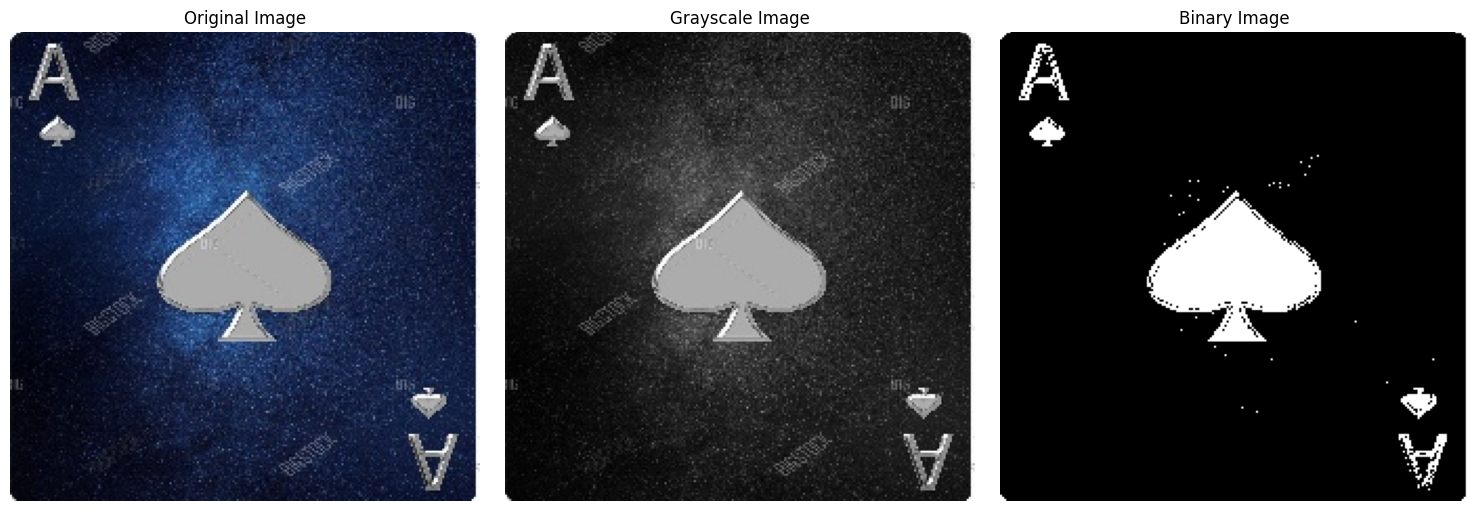

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(selected_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

# Grayscale image
axes[1].imshow(grayscale_image, cmap='gray')
axes[1].set_title("Grayscale Image")
axes[1].axis('off')

# Binary image
axes[2].imshow(binary_image, cmap='gray')
axes[2].set_title("Binary Image")
axes[2].axis('off')

plt.tight_layout()
plt.show()

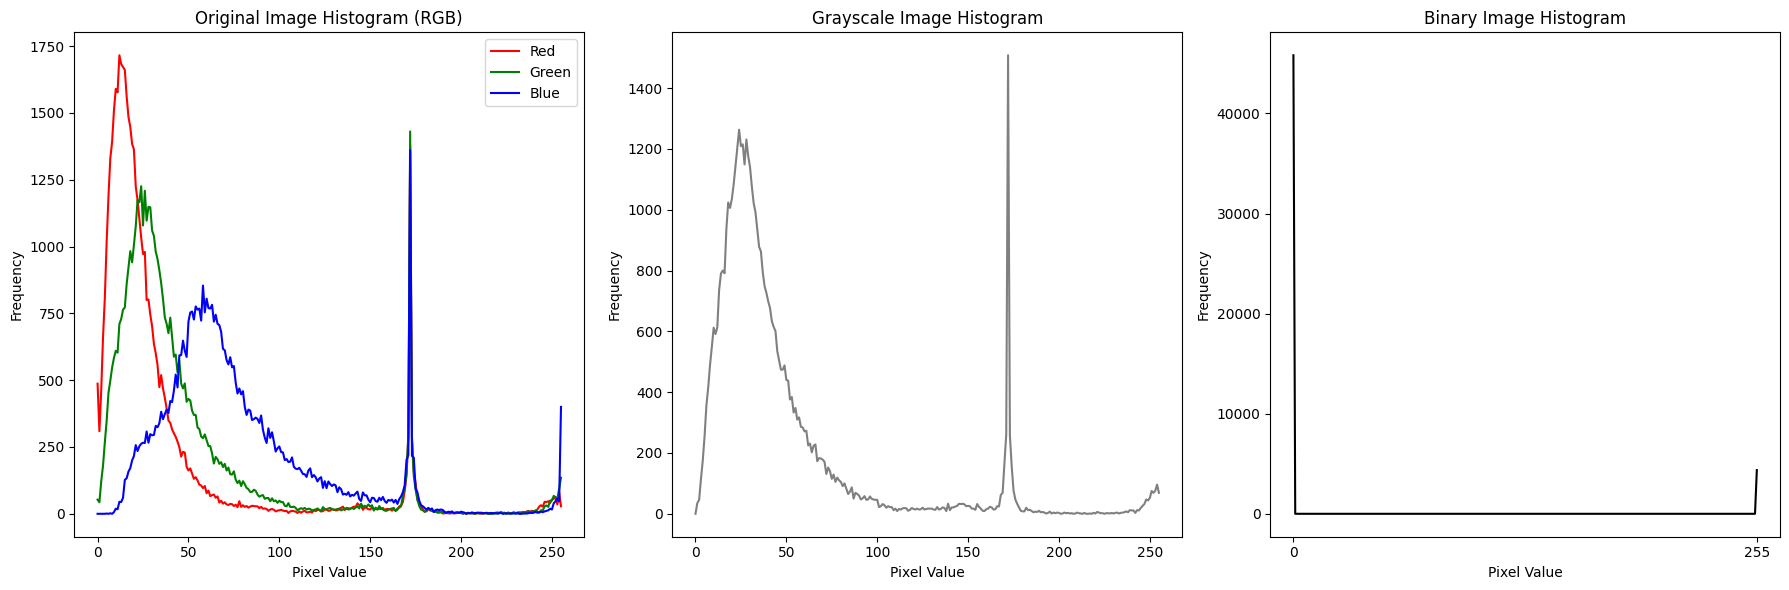

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a figure with three subplots for the histograms
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 2. Histogram for the original image (RGB)
if selected_image.mode == 'RGB':
    for i, color in enumerate(['red', 'green', 'blue']):
        hist = selected_image.getchannel(i).histogram()
        axes[0].plot(hist, color=color, label=color.capitalize())
    axes[0].set_title('Original Image Histogram (RGB)')
    axes[0].set_xlabel('Pixel Value')
    axes[0].set_ylabel('Frequency')
    axes[0].legend()
elif selected_image.mode == 'L':
    hist = selected_image.histogram()
    axes[0].plot(hist, color='gray')
    axes[0].set_title('Original Image Histogram (Grayscale)')
    axes[0].set_xlabel('Pixel Value')
    axes[0].set_ylabel('Frequency')


# 3. Histogram for the grayscale image
hist_gray = grayscale_image.histogram()
axes[1].plot(hist_gray, color='gray')
axes[1].set_title('Grayscale Image Histogram')
axes[1].set_xlabel('Pixel Value')
axes[1].set_ylabel('Frequency')

# 4. Histogram for the binary image
hist_binary = binary_image.histogram()
axes[2].plot(hist_binary, color='black')
axes[2].set_title('Binary Image Histogram')
axes[2].set_xlabel('Pixel Value')
axes[2].set_ylabel('Frequency')
axes[2].set_xticks([0, 255]) # Binary images only have 0 and 255

# 5. Adjust layout
plt.tight_layout()

# 6. Display the plot
plt.show()

In [ ]:
import os
from PIL import Image

# 1. Define the path to the source folder
source_folder = target_dir # Using the previously created folder with 200 images

# 2. Create a new directory named "grayscale_images"
grayscale_folder = "/content/drive/MyDrive/grayscale_images"
os.makedirs(grayscale_folder, exist_ok=True)

print(f"Source folder: {source_folder}")
print(f"Grayscale images will be saved to: {grayscale_folder}")

# 3. Iterate through each file in the source folder
for filename in os.listdir(source_folder):
    file_path = os.path.join(source_folder, filename)

    # 4. Check if it's an image file
    if os.path.isfile(file_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        try:
            # 5. Open the image using Pillow
            img = Image.open(file_path)

            # 6. Convert the image to grayscale
            grayscale_img = img.convert('L')

            # 7. Construct the save path for the grayscale image
            save_path = os.path.join(grayscale_folder, filename)

            # 8. Save the grayscale image to the new folder
            grayscale_img.save(save_path)
            # print(f"Converted and saved: {filename}") # Optional: uncomment to see progress

        except Exception as e:
            # 9. Include error handling
            print(f"Error processing {filename}: {e}")

print("Grayscale conversion complete.")
print(f"Number of files in grayscale folder: {len(os.listdir(grayscale_folder))}")

Source folder: /content/drive/MyDrive/cards_dataset_200
Grayscale images will be saved to: /content/drive/MyDrive/grayscale_images
Grayscale conversion complete.
Number of files in grayscale folder: 145


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# 1. Create a new directory named "grayscale_histograms" in Google Drive
grayscale_histograms_folder = "/content/drive/MyDrive/grayscale_histograms"
os.makedirs(grayscale_histograms_folder, exist_ok=True)

print(f"Grayscale histograms will be saved to: {grayscale_histograms_folder}")

# 2. Iterate through each grayscale image file in the grayscale_folder
for filename in os.listdir(grayscale_folder):
    file_path = os.path.join(grayscale_folder, filename)

    # 3. Check if it's an image file
    if os.path.isfile(file_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        try:
            # 4. Open the image using Pillow
            img = Image.open(file_path)

            # Ensure the image is in grayscale mode (although it should be from the previous step)
            if img.mode != 'L':
                print(f"Warning: {filename} is not in grayscale mode. Skipping histogram generation.")
                continue

            # 5. Calculate the histogram of the grayscale image
            hist = img.histogram()

            # 6. Create a plot for the histogram using matplotlib.pyplot
            plt.figure()
            plt.plot(hist, color='gray')

            # 7. Add a title to the histogram plot indicating the image filename
            plt.title(f"Histogram for {filename}")

            # Set the x-axis label to 'Pixel Value' and the y-axis label to 'Frequency'
            plt.xlabel("Pixel Value")
            plt.ylabel("Frequency")

            # 8. Save the histogram plot as an image file
            histogram_filename = os.path.splitext(filename)[0] + "_histogram.png"
            save_path = os.path.join(grayscale_histograms_folder, histogram_filename)
            plt.savefig(save_path)

            # 9. Close the plot to free up memory
            plt.close()
            # print(f"Generated and saved histogram for: {filename}") # Optional: uncomment to see progress

        except Exception as e:
            # 10. Include error handling
            print(f"Error processing {filename} for histogram: {e}")

print("Grayscale histogram generation complete.")
print(f"Number of files in grayscale histograms folder: {len(os.listdir(grayscale_histograms_folder))}")

Grayscale histograms will be saved to: /content/drive/MyDrive/grayscale_histograms
Grayscale histogram generation complete.
Number of files in grayscale histograms folder: 145


In [ ]:
import os

# Create a new directory named "rgb_images" in Google Drive
rgb_folder = "/content/drive/MyDrive/rgb_images"
os.makedirs(rgb_folder, exist_ok=True)

# Create a new directory named "binary_images" in Google Drive
binary_folder = "/content/drive/MyDrive/binary_images"
os.makedirs(binary_folder, exist_ok=True)

# Print messages confirming the creation of these directories and their paths
print(f"RGB images will be potentially stored in: {rgb_folder}")
print(f"Binary images will be potentially stored in: {binary_folder}")

RGB images will be potentially stored in: /content/drive/MyDrive/rgb_images
Binary images will be potentially stored in: /content/drive/MyDrive/binary_images


In [ ]:
# Define the path to the source folder containing original RGB images
# This is the dataset path downloaded from Kaggle Hub
source_folder_rgb = dataset_path

# Create a new directory named "rgb_histograms" in Google Drive
rgb_histograms_folder = "/content/drive/MyDrive/rgb_histograms"
os.makedirs(rgb_histograms_folder, exist_ok=True)

print(f"Original RGB images source folder: {source_folder_rgb}")
print(f"RGB histograms will be saved to: {rgb_histograms_folder}")

# Iterate through each file in the source folder recursively
rgb_histograms_count = 0
for root, dirs, files in os.walk(source_folder_rgb):
    for filename in files:
        file_path = os.path.join(root, filename)

        # Check if it's an image file
        if os.path.isfile(file_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            try:
                # Open the image using Pillow
                img = Image.open(file_path)

                # Check if the image is in RGB mode
                if img.mode == 'RGB':
                    # Calculate the histogram for each channel (Red, Green, Blue)
                    hist_r = img.getchannel('R').histogram()
                    hist_g = img.getchannel('G').histogram()
                    hist_b = img.getchannel('B').histogram()

                    # Create a plot using matplotlib.pyplot
                    plt.figure(figsize=(8, 6))
                    plt.plot(hist_r, color='red', label='Red')
                    plt.plot(hist_g, color='green', label='Green')
                    plt.plot(hist_b, color='blue', label='Blue')

                    # Add a title, labels, and legend
                    plt.title(f"RGB Histogram for {filename}")
                    plt.xlabel("Pixel Value")
                    plt.ylabel("Frequency")
                    plt.legend()

                    # Construct the save path for the histogram plot file
                    histogram_filename = os.path.splitext(filename)[0] + "_rgb_histogram.png"
                    save_path = os.path.join(rgb_histograms_folder, histogram_filename)

                    # Save the histogram plot
                    plt.savefig(save_path)

                    # Close the plot to free up memory
                    plt.close()
                    rgb_histograms_count += 1
                    # print(f"Generated and saved RGB histogram for: {filename}") # Optional: uncomment to see progress

                else:
                    print(f"Warning: {filename} is not in RGB mode ({img.mode}). Skipping histogram generation.")

            except Exception as e:
                # Include error handling
                print(f"Error processing {filename} for RGB histogram: {e}")

print("Original RGB histogram generation complete.")
print(f"Number of RGB histograms saved: {rgb_histograms_count}")

Original RGB images source folder: /kaggle/input/cards-image-datasetclassification
RGB histograms will be saved to: /content/drive/MyDrive/rgb_histograms


In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# 1. Define the path to the source folder containing the grayscale images
source_folder_grayscale = grayscale_folder # Using the previously created folder with grayscale images

# 2. Create a new directory named "binary_histograms" in Google Drive
binary_histograms_folder = "/content/drive/MyDrive/binary_histograms"
os.makedirs(binary_histograms_folder, exist_ok=True)

print(f"Source folder for grayscale images: {source_folder_grayscale}")
print(f"Binary histograms will be saved to: {binary_histograms_folder}")

# 4. Initialize a counter for the number of generated binary histograms.
binary_histograms_count = 0

# 5. Iterate through each file in the grayscale images folder
for filename in os.listdir(source_folder_grayscale):
    # 6. For each file, construct the full file path
    file_path = os.path.join(source_folder_grayscale, filename)

    # 7. Check if the current path is a file and if its extension is one of the supported image formats
    if os.path.isfile(file_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        # 8. Use a try-except block to handle potential errors
        try:
            # 9. Inside the try block:
            # Open the grayscale image using Pillow
            img = Image.open(file_path)

            # Ensure the image is in grayscale mode
            if img.mode != 'L':
                print(f"Warning: {filename} is not in grayscale mode ({img.mode}). Skipping binary histogram generation.")
                continue

            # Define a threshold for binary conversion (e.g., 128)
            threshold = 128

            # Convert the grayscale image to a binary image
            binary_image = img.point(lambda x: 0 if x < threshold else 255, '1')

            # Calculate the histogram of the binary image
            hist = binary_image.histogram()

            # Create a plot for the histogram
            plt.figure()
            plt.plot(hist, color='black')

            # Add a title to the histogram plot
            plt.title(f"Binary Histogram for {filename}")

            # Set the x-axis label and the y-axis label
            plt.xlabel("Pixel Value")
            plt.ylabel("Frequency")

            # Set the x-axis ticks to only show 0 and 255
            plt.xticks([0, 255])

            # Construct the save path for the histogram plot file
            histogram_filename = os.path.splitext(filename)[0] + "_binary_histogram.png"
            save_path = os.path.join(binary_histograms_folder, histogram_filename)

            # Save the histogram plot
            plt.savefig(save_path)

            # Close the plot to free up memory
            plt.close()

            # Increment the binary histograms counter
            binary_histograms_count += 1
            # print(f"Generated and saved binary histogram for: {filename}") # Optional: uncomment to see progress

        except Exception as e:
            # 10. Include error handling
            print(f"Error processing {filename} for binary histogram: {e}")

# 11. After the loop, print a message indicating that binary histogram generation is complete.
print("Binary histogram generation complete.")
# 12. Print the total number of binary histograms saved.
print(f"Number of binary histograms saved: {binary_histograms_count}")

In [ ]:
import os
from PIL import Image
import matplotlib.pyplot as plt

# 1. Define the path to the source folder containing the grayscale images
# Redefine grayscale_folder since it was not in the current session's scope
grayscale_folder = "/content/drive/MyDrive/grayscale_images"
source_folder_grayscale = grayscale_folder # Using the previously created folder with grayscale images

# 2. Create a new directory named "binary_histograms" in Google Drive
binary_histograms_folder = "/content/drive/MyDrive/binary_histograms"
os.makedirs(binary_histograms_folder, exist_ok=True)

print(f"Source folder for grayscale images: {source_folder_grayscale}")
print(f"Binary histograms will be saved to: {binary_histograms_folder}")

# 4. Initialize a counter for the number of generated binary histograms.
binary_histograms_count = 0

# 5. Iterate through each file in the grayscale images folder
for filename in os.listdir(source_folder_grayscale):
    # 6. For each file, construct the full file path
    file_path = os.path.join(source_folder_grayscale, filename)

    # 7. Check if the current path is a file and if its extension is one of the supported image formats
    if os.path.isfile(file_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        # 8. Use a try-except block to handle potential errors
        try:
            # 9. Inside the try block:
            # Open the grayscale image using Pillow
            img = Image.open(file_path)

            # Ensure the image is in grayscale mode
            if img.mode != 'L':
                print(f"Warning: {filename} is not in grayscale mode ({img.mode}). Skipping binary histogram generation.")
                continue

            # Define a threshold for binary conversion (e.g., 128)
            threshold = 128

            # Convert the grayscale image to a binary image
            binary_image = img.point(lambda x: 0 if x < threshold else 255, '1')

            # Calculate the histogram of the binary image
            hist = binary_image.histogram()

            # Create a plot for the histogram
            plt.figure()
            plt.plot(hist, color='black')

            # Add a title to the histogram plot
            plt.title(f"Binary Histogram for {filename}")

            # Set the x-axis label and the y-axis label
            plt.xlabel("Pixel Value")
            plt.ylabel("Frequency")

            # Set the x-axis ticks to only show 0 and 255
            plt.xticks([0, 255])

            # Construct the save path for the histogram plot file
            histogram_filename = os.path.splitext(filename)[0] + "_binary_histogram.png"
            save_path = os.path.join(binary_histograms_folder, histogram_filename)

            # Save the histogram plot
            plt.savefig(save_path)

            # Close the plot to free up memory
            plt.close()

            # Increment the binary histograms counter
            binary_histograms_count += 1
            # print(f"Generated and saved binary histogram for: {filename}") # Optional: uncomment to see progress

        except Exception as e:
            # 10. Include error handling
            print(f"Error processing {filename} for binary histogram: {e}")

# 11. After the loop, print a message indicating that binary histogram generation is complete.
print("Binary histogram generation complete.")
# 12. Print the total number of binary histograms saved.
print(f"Number of binary histograms saved: {binary_histograms_count}")

In [ ]:
import os
import cv2
import numpy as np
from PIL import Image

# Define the source folder for grayscale images and the target folder for edge detection results
grayscale_folder = "/content/drive/MyDrive/grayscale_images"
edge_detection_folder = "/content/drive/MyDrive/edge_detection_images"
os.makedirs(edge_detection_folder, exist_ok=True)

print(f"Source folder for grayscale images: {grayscale_folder}")
print(f"Edge detection images will be saved to: {edge_detection_folder}")

# Iterate through each file in the grayscale images folder
for filename in os.listdir(grayscale_folder):
    file_path = os.path.join(grayscale_folder, filename)

    # Check if the current path is a file and if it's an image
    if os.path.isfile(file_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg')):
        try:
            # Open the image using Pillow and convert to NumPy array for OpenCV
            img_pil = Image.open(file_path)
            img_gray = np.array(img_pil)

            # Ensure the image is in grayscale (should be from the source folder)
            if len(img_gray.shape) == 3:
                img_gray = cv2.cvtColor(img_gray, cv2.COLOR_RGB2GRAY)

            # Perform Canny edge detection
            canny_edges = cv2.Canny(img_gray, 100, 200) # You can adjust the thresholds

            # Perform Sobel edge detection (calculate gradients in x and y directions)
            sobelx = cv2.Sobel(img_gray, cv2.CV_64F, 1, 0, ksize=5)
            sobely = cv2.Sobel(img_gray, cv2.CV_64F, 0, 1, ksize=5)
            sobel_edges = cv2.magnitude(sobelx, sobely) # Combine gradients

            # Convert the Sobel result back to uint8 for saving
            sobel_edges = cv2.normalize(sobel_edges, None, 0, 255, cv2.NORM_MINMAX, cv2.CV_8U)


            # Construct the save paths
            base_filename = os.path.splitext(filename)[0]
            canny_save_path = os.path.join(edge_detection_folder, f"{base_filename}_canny.png")
            sobel_save_path = os.path.join(edge_detection_folder, f"{base_filename}_sobel.png")

            # Save the edge detection images
            cv2.imwrite(canny_save_path, canny_edges)
            cv2.imwrite(sobel_save_path, sobel_edges)

            # print(f"Generated and saved edge detection images for: {filename}") # Optional: uncomment to see progress

        except Exception as e:
            print(f"Error processing {filename} for edge detection: {e}")

print("Edge detection complete.")
print(f"Number of files in edge detection folder: {len(os.listdir(edge_detection_folder))}")